# Computer Exercise 13.11 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 13.11 Advanced Global Optimization — *Benchmark: PSO vs CMA-ES vs DE*
> **풀이 일자**: Day 56
> **언어**: Python 3 (NumPy / Matplotlib)

## 1. 문제 (원문)

> **3.** Using a **fixed function-evaluation budget**, compare three population/distribution based
> global optimizers — **PSO**, **CMA-ES**, and **Differential Evolution (DE)** — on a suite of
> multimodal test functions (*Ackley*, *Rastrigin*, *Griewank*, *Rosenbrock*) in $d=4$ dimensions.
> Report the **success rate** (fraction of random restarts that reach the global optimum within a
> tolerance) and the **mean best value** for each method/function pair, and discuss which structures
> favor which method in light of the **No Free Lunch** theorem.

### 한국어 풀이용 정리
**동일한 함수호출 예산**에서 세 전역 최적화기 — **PSO·CMA-ES·DE** — 를 다봉 벤치마크 묶음
(Ackley·Rastrigin·Griewank·Rosenbrock, $d{=}4$)에 맞붙인다. 각 (방법, 함수)에 대해 다중 재시작의
**성공률**(허용오차 내 전역최적 도달 비율)과 **평균 최선값**을 보고하고, 어떤 문제 구조가 어떤
방법에 유리한지 **No Free Lunch** 관점에서 토의한다.

## 2. 수학적 배경

### 2.1 공정 비교의 원칙 — 예산 고정
전역 최적화기는 내부 파라미터(개체 수, 세대 수)가 제각각이라 **반복 횟수**로 비교하면 불공정하다.
따라서 모든 방법에 **동일한 함수호출 예산 $B$** 를 부여하고, 호출 카운터가 $B$ 에 닿으면 즉시 멈춘다.
지표는 다음 두 가지:

$$
\text{success rate} = \frac{1}{R}\sum_{r=1}^{R}\mathbb{1}\!\left[f_\text{best}^{(r)} - f^\* < \tau\right],
\qquad
\overline{f_\text{best}} = \frac{1}{R}\sum_{r=1}^{R} f_\text{best}^{(r)} ,
$$

$R$ 은 재시작 수, $\tau$ 는 허용오차.

### 2.2 벤치마크 함수의 구조 ($d=4$, 전역최소 $f^\*=0$)
- **Ackley**: 거의 단봉의 큰 깔때기 + 잔물결 → 전역 구조가 또렷, 개체군법에 우호적.
- **Rastrigin**: 규칙적 격자형 국소최소 $\sim 11^d$ 개 → **가장 어려운** 다봉, 다양성 유지가 관건.
- **Griewank**: 곱 항이 만드는 잔물결 국소최소. *고차원*에서는 평탄해져 거의 볼록이 되지만,
  여기처럼 **저차원($d{=}4$)에서는 여전히 강한 다봉**이라 좁은 예산에서 모두 고전한다.
- **Rosenbrock**: 다봉이 아니라 **악조건 곡선 골짜기** → 공분산 학습(CMA-ES)의 고정밀 수렴에
  유리하지만, 차분 벡터로 골짜기를 따라가는 **DE 도 경쟁력** 있다.

### 2.3 No Free Lunch
모든 문제에 평균적으로 우월한 최적화기는 없다(Wolpert–Macready). **함수 구조에 대한 가정**이
방법의 강점을 만든다: CMA-ES 는 악조건/회전, DE 는 평탄·다봉, PSO 는 빠른 정보공유에 강하다.

$$\boxed{\;\text{고정 예산 } B \Rightarrow \text{success rate·mean } f_\text{best} \text{ 로 공정 비교; 만능은 없다}\;}$$

## 3. 풀이 흐름

1. **함수 묶음**: Ackley·Rastrigin·Griewank·Rosenbrock($d{=}4$)과 각 영역·전역최소 정의.
2. **호출 카운터**: 모든 목적함수를 래핑해 평가 횟수를 세고, 예산 초과 시 `StopBudget` 발생.
3. **세 최적화기**: PSO·DE 는 직접 구현(예산 기반 종료), CMA-ES 는 Problem 2 구현을 예산 종료로 적응.
4. **공정 예산**: 모든 방법에 $B=10{,}000$ 평가 동일 부여.
5. **반복 실험**: 각 (방법, 함수)에 $R=12$ 재시작, 성공률($f_\text{best}<\tau$)·평균 최선값 집계.
6. **표·히트맵**: 성공률 행렬을 표와 히트맵으로 정리.
7. **막대 비교**: 함수별 세 방법의 성공률 그룹 막대.
8. **해석**: 구조↔강점 매핑과 No Free Lunch 결론.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.3e}")

# ---- 벤치마크 함수 (전역최소 f*=0) ----
def ackley(x):
    x = np.asarray(x, float); d = x.size
    return float(-20*np.exp(-0.2*np.sqrt(np.sum(x**2)/d))
                 - np.exp(np.sum(np.cos(2*np.pi*x))/d) + 20 + np.e)

def rastrigin(x):
    x = np.asarray(x, float)
    return float(10*x.size + np.sum(x**2 - 10*np.cos(2*np.pi*x)))

def griewank(x):
    x = np.asarray(x, float)
    return float(np.sum(x**2)/4000 - np.prod(np.cos(x/np.sqrt(np.arange(1, x.size+1)))) + 1)

def rosenbrock(x):
    x = np.asarray(x, float)
    return float(np.sum(100*(x[1:]-x[:-1]**2)**2 + (1-x[:-1])**2))

DIM = 4
PROBLEMS = {
    "Ackley":     dict(f=ackley,     bound=32.0,  opt=np.zeros(DIM)),
    "Rastrigin":  dict(f=rastrigin,  bound=5.12,  opt=np.zeros(DIM)),
    "Griewank":   dict(f=griewank,   bound=50.0,  opt=np.zeros(DIM)),
    "Rosenbrock": dict(f=rosenbrock, bound=5.0,   opt=np.ones(DIM)),
}

class StopBudget(Exception):
    pass

class Counter:
    # 예산 기반 함수호출 래퍼: best 추적, 예산 초과 시 StopBudget
    def __init__(self, f, budget):
        self.f, self.budget, self.n = f, budget, 0
        self.best_f, self.best_x = np.inf, None
    def __call__(self, x):
        if self.n >= self.budget:
            raise StopBudget()
        self.n += 1
        v = self.f(x)
        if v < self.best_f:
            self.best_f, self.best_x = v, np.asarray(x, float).copy()
        return v

In [2]:
# ---- PSO (예산 종료, gbest, 관성 0.9->0.4) ----
def opt_pso(cf, bound, dim, rng, N=30):
    X = rng.uniform(-bound, bound, (N, dim))
    vmax = 0.2 * 2 * bound
    V = rng.uniform(-vmax, vmax, (N, dim)) * 0.1
    try:
        fX = np.array([cf(x) for x in X])
        P, fP = X.copy(), fX.copy()
        gi = int(np.argmin(fP)); g = P[gi].copy()
        it = 0
        while True:
            w = max(0.4, 0.9 - 0.5 * it / 400); it += 1
            r1 = rng.random((N, dim)); r2 = rng.random((N, dim))
            V = w*V + 1.5*r1*(P - X) + 1.5*r2*(g - X)
            V = np.clip(V, -vmax, vmax)
            X = np.clip(X + V, -bound, bound)
            fX = np.array([cf(x) for x in X])
            imp = fX < fP; P[imp] = X[imp]; fP[imp] = fX[imp]
            gi = int(np.argmin(fP)); g = P[gi].copy()
    except StopBudget:
        pass

# ---- DE/rand/1/bin (예산 종료) ----
def opt_de(cf, bound, dim, rng, N=40, F=0.5, CR=0.9):
    X = rng.uniform(-bound, bound, (N, dim))
    try:
        fX = np.array([cf(x) for x in X])
        while True:
            for i in range(N):
                idxs = [j for j in range(N) if j != i]
                a, b, c = X[rng.choice(idxs, 3, replace=False)]
                mut = np.clip(a + F*(b - c), -bound, bound)
                cross = rng.random(dim) < CR
                if not cross.any():
                    cross[rng.integers(dim)] = True
                trial = np.where(cross, mut, X[i])
                ft = cf(trial)
                if ft < fX[i]:
                    X[i], fX[i] = trial, ft
    except StopBudget:
        pass

# ---- CMA-ES (예산 종료, 단일 실행/재시작 없음) ----
def opt_cma(cf, bound, dim, rng, sigma0=None):
    m = rng.uniform(-bound, bound, dim)
    sigma = sigma0 if sigma0 else 0.3 * 2 * bound
    N = dim
    lam = 4 + int(3*np.log(N)); mu = lam // 2
    w = np.log(mu+0.5) - np.log(np.arange(1, mu+1)); w /= w.sum()
    mueff = 1/np.sum(w**2)
    cc = (4+mueff/N)/(N+4+2*mueff/N); cs = (mueff+2)/(N+mueff+5)
    c1 = 2/((N+1.3)**2+mueff)
    cmu = min(1-c1, 2*(mueff-2+1/mueff)/((N+2)**2+mueff))
    damps = 1 + 2*max(0, np.sqrt((mueff-1)/(N+1))-1) + cs
    chiN = np.sqrt(N)*(1-1/(4*N)+1/(21*N**2))
    pc = np.zeros(N); ps = np.zeros(N); C = np.eye(N); B = np.eye(N); D = np.ones(N)
    invsqrtC = np.eye(N); gen = 0
    try:
        while True:
            Y = rng.standard_normal((lam, N)) @ (B*D).T
            Xs = m + sigma*Y
            fs = np.array([cf(x) for x in Xs])
            o = np.argsort(fs); Xs, Y = Xs[o], Y[o]
            m_old = m.copy()
            m = (w[:, None]*Xs[:mu]).sum(0); yw = (w[:, None]*Y[:mu]).sum(0)
            ps = (1-cs)*ps + np.sqrt(cs*(2-cs)*mueff)*(invsqrtC @ yw)
            gen += 1
            hsig = (np.linalg.norm(ps)/np.sqrt(1-(1-cs)**(2*gen))/chiN < 1.4+2/(N+1))
            pc = (1-cc)*pc + hsig*np.sqrt(cc*(2-cc)*mueff)*yw
            artmp = Y[:mu]
            C = ((1-c1-cmu)*C + c1*(np.outer(pc, pc)+(1-hsig)*cc*(2-cc)*C)
                 + cmu*(artmp.T*w) @ artmp)
            sigma *= np.exp((cs/damps)*(np.linalg.norm(ps)/chiN - 1))
            C = np.triu(C) + np.triu(C, 1).T
            D2, B = np.linalg.eigh(C); D2 = np.clip(D2, 1e-20, None); D = np.sqrt(D2)
            invsqrtC = B @ np.diag(1/D) @ B.T
    except StopBudget:
        pass

OPTIMIZERS = {"PSO": opt_pso, "DE": opt_de, "CMA-ES": opt_cma}

In [3]:
# ---- 고정 예산 벤치마크 ----
BUDGET = 10000
R = 12
TOL = 1e-2

succ = {m: {} for m in OPTIMIZERS}
meanf = {m: {} for m in OPTIMIZERS}
for pname, P in PROBLEMS.items():
    for mname, opt in OPTIMIZERS.items():
        s, fb = 0, []
        for r in range(R):
            rng = np.random.default_rng(10000 + r)
            cf = Counter(P["f"], BUDGET)
            try:
                opt(cf, P["bound"], DIM, rng)
            except StopBudget:
                pass
            fb.append(cf.best_f)
            if cf.best_f < TOL:
                s += 1
        succ[mname][pname] = s / R
        meanf[mname][pname] = float(np.mean(fb))

df_succ = pd.DataFrame(succ).T[list(PROBLEMS)]
print("Success rate (budget=%d evals, R=%d, tol=%.0e):" % (BUDGET, R, TOL))
df_succ

Success rate (budget=10000 evals, R=12, tol=1e-02):


,Ackley,Rastrigin,Griewank,Rosenbrock
PSO,1.000e+00,5.833e-01,8.333e-02,8.333e-02
DE,1.000e+00,1.000e+00,8.333e-02,7.500e-01
CMA-ES,1.000e+00,0.000e+00,8.333e-02,7.500e-01


In [4]:
# ---- 평균 최선값 표 ----
df_mean = pd.DataFrame(meanf).T[list(PROBLEMS)]
print("Mean best f (lower is better):")
df_mean

Mean best f (lower is better):


,Ackley,Rastrigin,Griewank,Rosenbrock
PSO,4.885e-15,4.146e-01,2.270e-02,4.857e-01
DE,1.924e-15,4.717e-09,2.306e-02,5.987e-02
CMA-ES,3.405e-15,4.726e+00,5.317e-02,9.254e-01


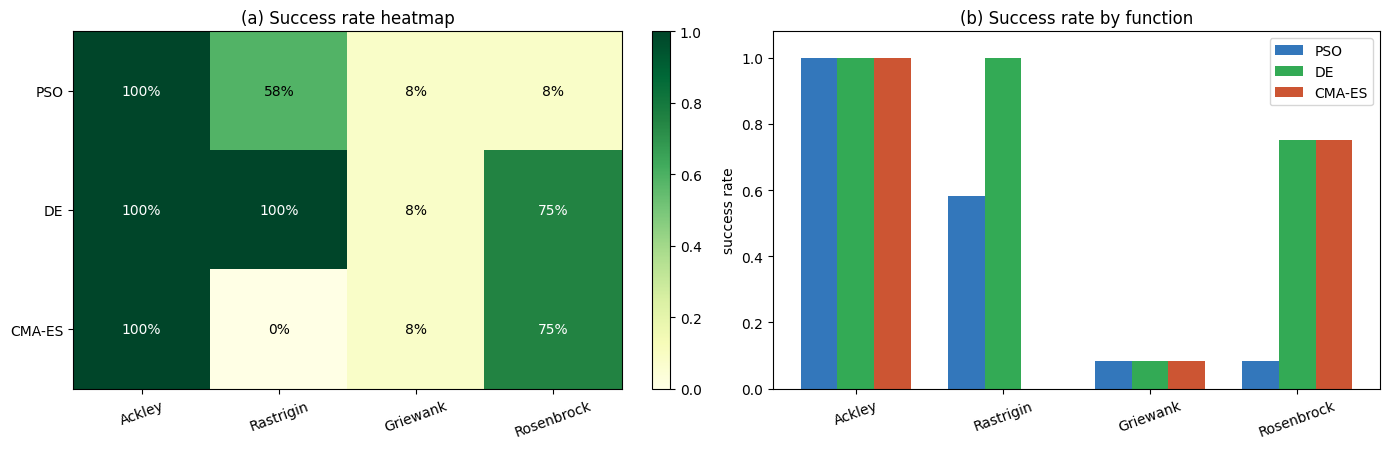

In [5]:
# ---- 시각화: 히트맵 + 그룹 막대 ----
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))

# (a) 성공률 히트맵
M = df_succ.values
im = ax[0].imshow(M, cmap="YlGn", vmin=0, vmax=1, aspect="auto")
ax[0].set_xticks(range(len(PROBLEMS))); ax[0].set_xticklabels(list(PROBLEMS), rotation=20)
ax[0].set_yticks(range(len(OPTIMIZERS))); ax[0].set_yticklabels(list(df_succ.index))
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax[0].text(j, i, f"{M[i,j]:.0%}", ha="center", va="center",
                   color="black" if M[i, j] < 0.6 else "white", fontsize=10)
ax[0].set_title("(a) Success rate heatmap")
fig.colorbar(im, ax=ax[0], fraction=0.046)

# (b) 함수별 그룹 막대
probs = list(PROBLEMS); methods = list(OPTIMIZERS)
x = np.arange(len(probs)); wd = 0.25
colors = {"PSO": "#3377bb", "DE": "#33aa55", "CMA-ES": "#cc5533"}
for k, m in enumerate(methods):
    vals = [succ[m][p] for p in probs]
    ax[1].bar(x + (k-1)*wd, vals, wd, label=m, color=colors[m])
ax[1].set_xticks(x); ax[1].set_xticklabels(probs, rotation=20)
ax[1].set_ylim(0, 1.08); ax[1].set_ylabel("success rate")
ax[1].set_title("(b) Success rate by function"); ax[1].legend()
plt.tight_layout(); plt.show()

## 4. 결과 해석

> 아래 수치는 위 셀의 실제 출력(예산 10,000 평가, 재시작 12회, 허용오차 $\tau{=}10^{-2}$, $d{=}4$)을
> 그대로 읽은 것이다.

1. **Ackley (큰 깔때기 + 잔물결)** — 세 방법 **모두 성공률 100%**, 평균 $f_\text{best}\!\sim\!10^{-15}$.
   전역 구조가 또렷한 깔때기라 다양성만 있으면 누구나 바닥을 찾는다 — *쉬운* 다봉 문제.
2. **Rastrigin (규칙적 격자 국소최소)** — 방법 간 차이가 **가장 극적**이다. **DE 100%**
   (평균 $f\!\approx\!5\times10^{-9}$)로 압도하고, **PSO ~58%**, **CMA-ES 0%**(평균 $f\!\approx\!4.7$).
   DE 의 차분 벡터·개체군 다양성이 격자형 국소최소를 잘 빠져나오는 반면, **재시작 없는 단일
   CMA-ES** 는 분포가 한 분지로 수축해 갇힌다(Problem 2 의 고정밀과 대조 — 같은 알고리즘도 *재시작
   유무*가 다봉에서 성패를 가른다).
3. **Griewank ($d{=}4$)** — 저차원에서는 잔물결 국소최소가 빽빽해 **세 방법 모두 ~8%** 로 고전한다.
   고차원이라면 평탄해져 쉬워지지만, $d{=}4$ 예산 내에서는 누구도 안정적으로 전역최소에 닿지
   못한다(평균값은 PSO·DE 가 CMA-ES 보다 약간 낮음).
4. **Rosenbrock (악조건 곡선 골짜기)** — **DE 와 CMA-ES 가 75%** 로 동률(허용오차 도달), **PSO 8%**.
   평균값으로는 **DE 가 가장 낮아**($\approx\!0.06$) 좁은 휜 골짜기를 차분 벡터로 잘 따라간다. 등방·고정
   스텝의 PSO 는 이 골짜기에서 가장 약하다.
5. **종합 / No Free Lunch** — 이 *울퉁불퉁한* 벤치마크 묶음에서는 **DE 가 가장 견고**했다. CMA-ES 는
   매끄럽거나 고정밀이 필요한 문제(Problem 2 의 Rosenbrock·Ackley)에 강하지만 **재시작 없이는** 격자형
   다봉(Rastrigin)에서 무너진다. PSO 는 중간. 즉 **어느 방법도 모든 함수에서 1위가 아니며**, 강점은
   *함수 구조에 대한 가정*에서 나온다 — 실무에서는 문제 성격에 맞춰 고르거나 **IPOP-재시작·
   포트폴리오·다중시작**으로 약점을 보완한다.

> **결론**: *동일 예산 비교에서 만능 전역법은 없다 — 격자형 Rastrigin·악조건 Rosenbrock 에서는
> 다양성의 DE 가 가장 견고했고, CMA-ES 의 강점(고정밀·악조건)은 재시작과 적절한 보폭이 있어야
> 살아난다. 방법 선택은 함수 구조에 대한 가정으로 정당화된다(No Free Lunch).*

**다음 Day 예고**: 챕터 13(최적화)의 국소(직선탐색·신뢰영역·준뉴턴)→제약(SQP/내부점)→무도함수
(Nelder–Mead/Hooke–Jeeves)→전역(SA·DE)→심화 전역(PSO·CMA-ES)까지 한 바퀴를 마쳤다. 다음
Day 는 **응용 사례연구**(실제 데이터 적합·하이퍼파라미터 탐색) 또는 새 챕터로 진도를 잇는다.